In [1]:
##### -*-coding:utf-8 -*-
# import all the libraries 
# python==3.9; jupyterlab==3.0.12; matplotlib==3.3.4; more-itertools==8.7.0;
# npTDMS==1.1.0; numpy==1.20.1; opencv-python==4.5.1.48; pandas==1.2.3; scipy==1.6.1; tifffile==2021.3.5
from __future__ import division
import os
from sympy import *
from sympy import coth
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from nptdms import TdmsFile
import sys
# %matplotlib widget
%matplotlib inline
# print(sys.executable)

In [5]:
# read raw .tdms file with TdmsFile function
# name example: /Users/longfu/Library/CloudStorage/Dropbox/4-T7DNAp-SSB_NSMB/Figure2_imaging data_collected_Feb &Nov_2020_analyzed_May2023/1-Thesis writing analyzing 20 molecules_23may2023/20200121-012_typical data analysis/raw data/force measurement/20200121-140145  6nM gp2.5-atto647N + 144nM wt gp2.5 + 30nM DNAp and etal #012-002.tdms
filename = input('please type in the file name with absolute path:' )
tdms_file = TdmsFile(filename)

# please write down the starting time of exo and pol, the ending time of exo and pol

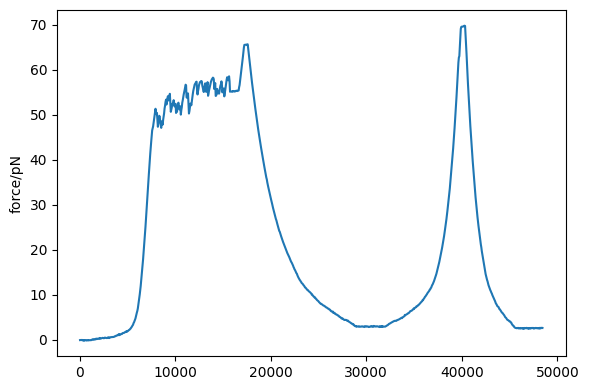

In [6]:
# run this step to find out the Time of ROI
time = tdms_file['FD Data']['Time (ms)'][:]
time = np.array(time)
force = tdms_file['FD Data']['Force Channel 0 (pN)'][:]
force = np.array(force)
distance = tdms_file['FD Data']['Distance 1 (um)'][:]
distance = np.array(distance)

# run this step to find out the Time of ROI
plt.figure(figsize=(6,4))
plt.plot(time,force)
# plt.plot(time,distance)
# plt.plot(distance,force)
plt.ylabel('force/pN')
plt.tight_layout()
plt.show()

In [28]:
# please enter cycle number of interest
cycle = input('please type in cycle number of interest(e.g.:01):')

# time_from_all = float(input('please type in the starting time of interest:'))
# time_to_all = float(input('please type in the ending time of interest:'))

time_from_exo = float(input('please type in the starting time of exo in ms:'))
time_to_exo = float(input('please type in the ending time of exo in ms:'))

time_from_pol = float(input('please type in the starting time of pol in ms:'))
time_to_pol = float(input('please type in the ending time of pol in ms:'))

In [29]:
# here you will select and analyze your interesting cycle with corresponding time range; 
# define a temporary index to compute time of ROI, and subsuquent ROI of force, distance
# indtemp_all = np.where((time <= time_to_all) & (time >= time_from_all))
indtemp_exo = np.where((time <= time_to_exo) & (time >= time_from_exo))
indtemp_pol = np.where((time <= time_to_pol) & (time >= time_from_pol))

# # all time range of event
# time_range_all = time[indtemp_all]
# force_range_all = force[indtemp_all]
# distance_range_all = distance[indtemp_all]

# exo time range of ROI
time_range_exo = time[indtemp_exo]
force_range_exo = force[indtemp_exo]
distance_range_exo = distance[indtemp_exo]

# pol time range of ROI
time_range_pol = time[indtemp_pol]
force_range_pol = force[indtemp_pol]
distance_range_pol = distance[indtemp_pol]

# all time range of ROI
time_range_all = np.append(time_range_exo, time_range_pol)
force_range_all = np.append(force_range_exo, force_range_pol)
distance_range_all = np.append(distance_range_exo, distance_range_pol)

In [30]:
print (time_range_pol)

[40338. 40388. 40438. 40488. 40538. 40588. 40638. 40688. 40738. 40788.
 40838. 40888. 40938. 40988. 41038. 41088. 41138. 41188. 41237. 41287.
 41337. 41387. 41437. 41487. 41537. 41587. 41637. 41687. 41738. 41788.
 41837. 41888. 41938. 41988. 42038. 42087. 42138. 42188. 42238. 42288.
 42338. 42388. 42438. 42488. 42538. 42588. 42638. 42688. 42738. 42788.
 42838. 42888. 42938. 42987. 43037. 43087. 43137. 43187. 43237. 43287.
 43337. 43387. 43437. 43487. 43537. 43587. 43637. 43687. 43737. 43787.
 43837. 43887. 43937. 43987. 44037. 44087. 44137. 44187. 44237. 44287.
 44337. 44387. 44437. 44487. 44537. 44587. 44637. 44687. 44736. 44786.
 44836. 44886. 44936. 44986. 45036. 45086. 45136. 45186. 45236. 45286.
 45336. 45386. 45437. 45487. 45537. 45587. 45637.]


In [35]:
# parameters for tWLC model: Peter Gross, et al. Nature Physics volume 7, pages731–736(2011)
# dsDNA contour length Lc = 2.85056um; persistent length Lp = 56nm
# the twist rigidity C=440 pN nm2;
# the stretching modulus S=1500 pN;
# the twist–stretch coupling g(F) is given by: g(F) =g0+g1F,where g0=−637 pN nm, g1=17 nm
EEDds,Lc,F,Lp,C,g0,g1,S = symbols('EEDds Lc F Lp C g0 g1 S', real=True)
C = 440
g0= -637
g1 = 17
Lc = 2.85056
Lp = 56
S = 1500
# tWLC model expression:
def tWLC(F):
    EEDds = Lc*(1-0.5*(4.1/(F*Lp))**0.5 + C*F/(-(g0+g1*F)**2 + S*C))
    return (EEDds)

# parameters for FJC model: Smith, S. B., et al. Science 271, 795–799 (1996).
# ssDNA contour length Lss = 4.69504um,
# Kuhn length b = 1.5nm (persistent length is 0.75nm),
# the stretching modulus S=800pN
EEDss,Lss,b,Sss = symbols('EEDss Lss b Sss', real=True)
Lss = 4.69504
b = 1.45
Sss = 800
# FJC model expression:
def FJC(F):
    EEDss = []
    for Fext in F:
        x  = Lss * (coth(Fext * b / 4.1) - 4.1 / (Fext * b)) * (1 + Fext / Sss)
        EEDss.append(x)
    EEDss = np.array(EEDss)
    return (EEDss)

# EEDss,Lss,b,Sss,Fext = symbols('EEDss Lss b Sss Fext', real=True)
# Lss = 4.69504
# b = 1.5
# Sss = 800
# # FJC model expression:
# def FJC(Fext):
#     EEDss  = Lss * (coth(Fext * b / 4.1) - 4.1 / (Fext * b)) * (1 + Fext / Sss)
#     return (EEDss)

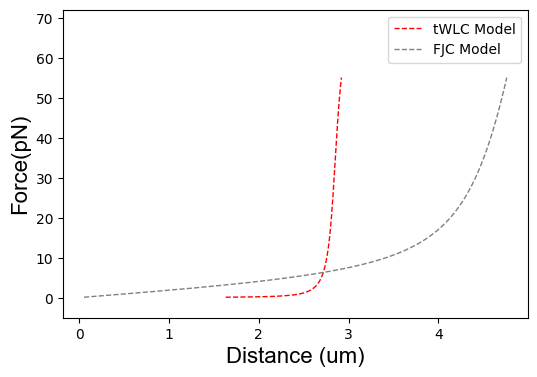

<Figure size 640x480 with 0 Axes>

In [36]:
Force = np.linspace(0.1,55,1000)

plt.figure(figsize=(6,4))
font = {'family': 'Arial', 'weight': 'normal', 'size': 16}


plt.xlabel('Distance (um)',fontdict=font)
plt.ylabel('Force(pN)',fontdict=font)
plt.plot(tWLC(Force),Force,color='red', linestyle='dashed',linewidth=1, label='tWLC Model')
plt.plot(FJC(Force),Force,color='gray',  linestyle='dashed',linewidth=1,label='FJC Model')

plt.legend()
# plt.title('Experimental Data fit to tWLC and FJC Model',fontdict=font)
plt.ylim(-5,72)

plt.show()
plt.tight_layout()

# you can only see experimental data after you run the next code block 

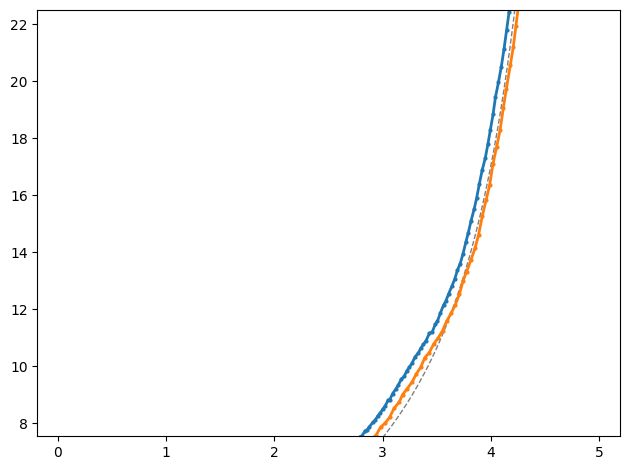

<Figure size 640x480 with 0 Axes>

In [ ]:
# Default bead size = 1.76um, by running this code to fit the right bead size
bead_size = 1.85

plt.figure()
# plt.plot(tWLC(Force),Force,color='red', linestyle='dashed',linewidth=1, label='WLC Model')
plt.plot(FJC(Force),Force,color='gray',  linestyle='dashed',linewidth=1,label='FJC Model')

# plot experimental data together with 
plt.plot(distance_range_exo - bead_size, force_range_exo, marker='o', linestyle='solid',linewidth=2, markersize=2,label='Stretching Data')
plt.plot(distance_range_pol - bead_size, force_range_pol, marker='o', linestyle='solid',linewidth=2, markersize=2,label='Retraction Data')
plt.ylim (7.55,25)
# plt.legend()
# plt.xlabel('Distance (um)',fontdict=font)
# plt.ylabel('Force(pN)',fontdict=font)
plt.tight_layout()
plt.show()

    
plt.savefig(filename.replace('.tdms', '-cycle#') + cycle + '-zoom10'+'.png', dpi=300)
plt.savefig(filename.replace('.tdms', '-cycle#') + cycle + '-zoom10'+'.eps', dpi=300)